# BSS decompositions

Stage 1 for the V2a workflow. This notebook fits the configured linear BSS methods and saves decomposition artifacts only: components, spectra, mixing matrices, means, metadata, summary tables, and diagnostic figures.

Run this before `cluster_clean_reconstruct.ipynb`. Component selection and cleaned-trace reconstruction happen in the next notebook, which loads these saved artifacts.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")

from ica_denoising.bss_notebook import (
    BSS_METHODS,
    available_datasets,
    load_traces,
    output_directory,
    resolve_bss_component_selection,
    run_bss_decomposition,
    summarize_decomposition_results,
)


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


In [2]:
DATASET_KEY = "v2a-RSNs/220210_F1_run6_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS)
N_COMPONENTS = None
PCA_COMPONENTS = None
SOBI_JADE_PCA_VARIANCE_THRESHOLD = None
TOLERANCE = 0.0001
MAX_ITERATIONS = 500
RANDOM_STATE = 0
SAVE_DECOMPOSITION_OUTPUTS = True
PLOT_DPI = 300

available_datasets(PROJECT_ROOT).query("group == 'v2a-RSNs'")


,key,group,data_name,trace_path,exists,default_n_components,sample_rate_hz,recording_id,fish_id,run_id,modality,tail_angle_exists,notes
2,v2a-RSNs/220119_F2_run11_fluorescence,v2a-RSNs,220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,True,NaN,6.0268,220119_F2_run11,220119_F2,run11,fluorescence,True,Discovered V2a RSN recording.
3,v2a-RSNs/220119_F2_run11_spike_rate,v2a-RSNs,220119_F2_run11_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_spik...,True,NaN,6.0268,220119_F2_run11,220119_F2,run11,spike_rate,True,Discovered V2a RSN recording.
4,v2a-RSNs/220127_F4_run2_fluorescence,v2a-RSNs,220127_F4_run2_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220127_F4_run2/220127_F4_F4_run2_after_dec_ce...,True,NaN,5.2962,220127_F4_run2,220127_F4,run2,fluorescence,True,Discovered V2a RSN recording.
5,v2a-RSNs/220127_F4_run2_spike_rate,v2a-RSNs,220127_F4_run2_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220127_F4_run2/220127_F4_F4_run2_after_dec_ce...,True,NaN,5.2962,220127_F4_run2,220127_F4,run2,spike_rate,True,Discovered V2a RSN recording.
6,v2a-RSNs/220210_F1_run6_fluorescence,v2a-RSNs,220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_fluore...,True,NaN,5.5573,220210_F1_run6,220210_F1,run6,fluorescence,True,Discovered V2a RSN recording.
7,v2a-RSNs/220210_F1_run6_spike_rate,v2a-RSNs,220210_F1_run6_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_spike_...,True,NaN,5.5573,220210_F1_run6,220210_F1,run6,spike_rate,True,Discovered V2a RSN recording.
8,v2a-RSNs/220210_F2_run5_fluorescence,v2a-RSNs,220210_F2_run5_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F2_run5/220210_F2_F2_run5_cells_fluore...,True,NaN,5.5573,220210_F2_run5,220210_F2,run5,fluorescence,True,Discovered V2a RSN recording.
9,v2a-RSNs/220210_F2_run5_spike_rate,v2a-RSNs,220210_F2_run5_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F2_run5/220210_F2_F2_run5_cells_spike_...,True,NaN,5.5573,220210_F2_run5,220210_F2,run5,spike_rate,True,Discovered V2a RSN recording.


In [3]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
component_plan = pd.DataFrame(
    [
        {
            "method": method,
            "n_components": selection.n_components,
            "pca_components": selection.pca_components,
            "pca_variance_threshold": selection.pca_variance_threshold,
            "pca_explained_variance_ratio": selection.pca_explained_variance_ratio,
            "component_selection_mode": selection.component_selection_mode,
        }
        for method in METHODS_TO_RUN
        for selection in [
            resolve_bss_component_selection(
                traces,
                method,
                n_components=N_COMPONENTS,
                pca_components=PCA_COMPONENTS,
                pca_variance_threshold=SOBI_JADE_PCA_VARIANCE_THRESHOLD,
            )
        ]
    ]
)
output_dirs = {
    method: output_directory(
        method,
        OUTPUT_DATA_NAME,
        PROJECT_ROOT,
        analysis_kind="linear",
        dataset_group=dataset.group,
    )
    for method in METHODS_TO_RUN
}
dataset_output_dir = next(iter(output_dirs.values())).parent
figure_dir = dataset_output_dir / "figures"
if SAVE_DECOMPOSITION_OUTPUTS:
    figure_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {dataset.key}")
print(f"Trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"Trace shape (neurons x frames): {traces.shape}")
print(f"Sample rate: {dataset.sample_rate_hz:g} Hz")
display(component_plan)
pd.DataFrame({"method": output_dirs.keys(), "output_dir": output_dirs.values()})


Dataset: v2a-RSNs/220210_F1_run6_fluorescence
Trace file: data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_fluorescence_signals.npy
Trace shape (neurons x frames): (412, 3316)
Sample rate: 5.5573 Hz


,method,n_components,pca_components,pca_variance_threshold,pca_explained_variance_ratio,component_selection_mode
0,fastica,412,None,None,None,full_trace_count
1,infomax,412,None,None,None,full_trace_count
2,sobi,412,None,None,None,full_trace_count
3,jade,412,None,None,None,full_trace_count


,method,output_dir
0,fastica,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica
1,infomax,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/infomax
2,sobi,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/sobi
3,jade,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/jade


Saved raw trace preview: outputs/linear/v2a-RSNs/220210_F1_run6/figures/raw_trace_preview_220210_F1_run6_fluorescence.png


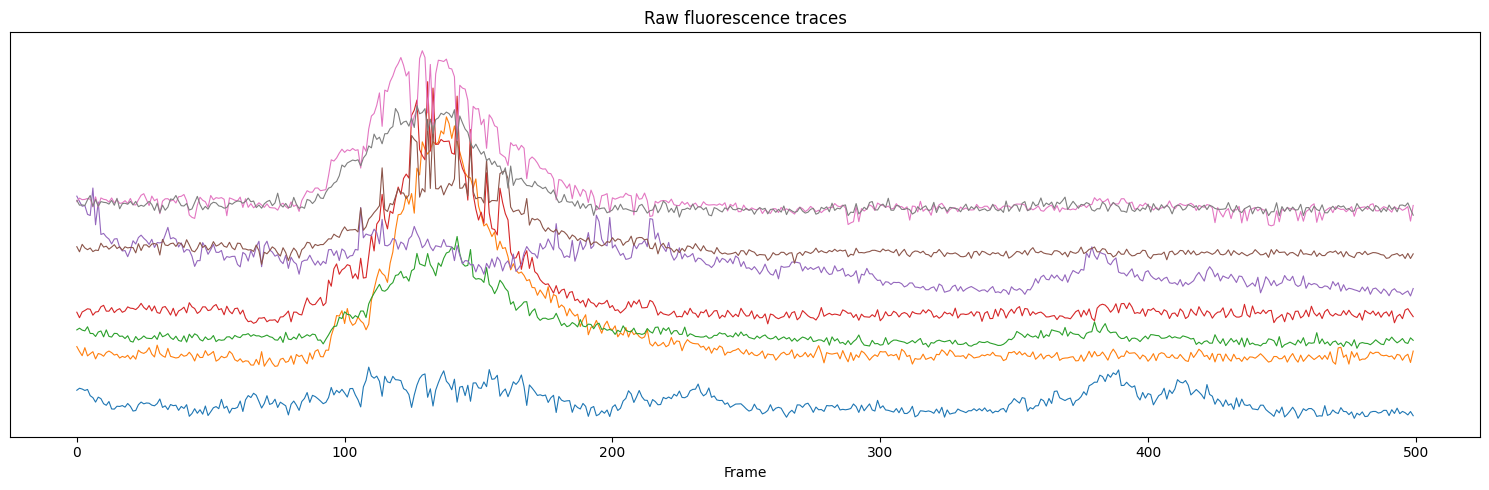

In [4]:
fig, ax = plt.subplots(figsize=(15, 5))
time_slice = slice(0, min(500, traces.shape[1]))
shown = range(min(8, traces.shape[0]))
offset = float(np.nanstd(traces[:, time_slice])) or 1.0
for row, neuron in enumerate(shown):
    ax.plot(traces[neuron, time_slice] + row * offset, lw=0.8)
ax.set(title="Raw fluorescence traces", xlabel="Frame", yticks=[])
fig.tight_layout()
raw_trace_plot_path = figure_dir / f"raw_trace_preview_{dataset.data_name}.png"
if SAVE_DECOMPOSITION_OUTPUTS:
    fig.savefig(raw_trace_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved raw trace preview: {raw_trace_plot_path.relative_to(PROJECT_ROOT)}")


In [5]:
results = {}
for method in METHODS_TO_RUN:
    plan_row = component_plan[component_plan["method"] == method].iloc[0]
    print(
        f"Running {method} with n_components={plan_row['n_components']}, "
        f"pca_components={plan_row['pca_components']}, "
        f"mode={plan_row['component_selection_mode']}"
    )
    results[method] = run_bss_decomposition(
        dataset_key=DATASET_KEY,
        method=method,
        n_components=N_COMPONENTS,
        pca_components=PCA_COMPONENTS,
        pca_variance_threshold=SOBI_JADE_PCA_VARIANCE_THRESHOLD,
        save_outputs=SAVE_DECOMPOSITION_OUTPUTS,
        project_root=PROJECT_ROOT,
        tol=TOLERANCE,
        max_iter=MAX_ITERATIONS,
        random_state=RANDOM_STATE,
        analysis_kind="linear",
        output_data_name_override=OUTPUT_DATA_NAME,
    )

summary = summarize_decomposition_results(results)
summary_path = dataset_output_dir / "decomposition_summary.csv"
if SAVE_DECOMPOSITION_OUTPUTS:
    summary.to_csv(summary_path, index=False)
    print(f"Saved decomposition summary: {summary_path.relative_to(PROJECT_ROOT)}")
summary


Running fastica with n_components=412, pca_components=None, mode=full_trace_count
Running infomax with n_components=412, pca_components=None, mode=full_trace_count
Running sobi with n_components=412, pca_components=None, mode=full_trace_count


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.4 * len(results)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (method, result) in zip(axes, results.items()):
    for component in range(min(8, result.ic_comps.shape[1])):
        ax.plot(result.ic_comps[:500, component] + component * 4, lw=0.7)
    ax.set(title=f"{method}: first independent components", yticks=[])
axes[-1].set_xlabel("Frame")
fig.tight_layout()
ic_preview_path = figure_dir / f"decomposition_ic_preview_{dataset.data_name}.png"
if SAVE_DECOMPOSITION_OUTPUTS:
    fig.savefig(ic_preview_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved IC preview: {ic_preview_path.relative_to(PROJECT_ROOT)}")


In [ ]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2.4 * len(results)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (method, result) in zip(axes, results.items()):
    freqs = np.linspace(0.0, float(dataset.sample_rate_hz) / 2.0, result.IC_ft.shape[1])
    spectra = np.maximum(result.IC_ft, np.finfo(float).eps)
    for component in range(min(12, spectra.shape[0])):
        ax.plot(freqs, np.log(spectra[component]), lw=0.7, alpha=0.75)
    ax.set_xlim(0.0, min(1.0, float(dataset.sample_rate_hz) / 2.0))
    ax.set(title=f"{method}: IC log spectra", ylabel="log PSD")
axes[-1].set_xlabel("Frequency (Hz)")
fig.tight_layout()
spectrum_preview_path = figure_dir / f"decomposition_spectrum_preview_{dataset.data_name}.png"
if SAVE_DECOMPOSITION_OUTPUTS:
    fig.savefig(spectrum_preview_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved spectrum preview: {spectrum_preview_path.relative_to(PROJECT_ROOT)}")


In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4), squeeze=False)
for ax, (method, result) in zip(axes.ravel(), results.items()):
    vmax = np.nanpercentile(np.abs(result.A), 98) or 1.0
    image = ax.imshow(result.A, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set(title=f"{method}: mixing", xlabel="Component", ylabel="Neuron")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
mixing_preview_path = figure_dir / f"decomposition_mixing_preview_{dataset.data_name}.png"
if SAVE_DECOMPOSITION_OUTPUTS:
    fig.savefig(mixing_preview_path, dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved mixing preview: {mixing_preview_path.relative_to(PROJECT_ROOT)}")


In [ ]:
for method, result in results.items():
    print(f"{method}: {result.output_dir.relative_to(PROJECT_ROOT)}")
    for label, artifact_path in result.saved_paths.items():
        print(f"  {label}: {artifact_path.relative_to(PROJECT_ROOT)}")
if SAVE_DECOMPOSITION_OUTPUTS:
    print(f"summary: {summary_path.relative_to(PROJECT_ROOT)}")
    print(f"figures: {figure_dir.relative_to(PROJECT_ROOT)}")
